In [1]:
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from matplotlib.collections import LineCollection

plt.style.use("seaborn-v0_8-whitegrid")
torch.set_printoptions(sci_mode=False)
np.set_printoptions(suppress=True)

DATASET_NAME = "mesh_gnn_1000_to_3500_splits_4_radius_0_8_candidate_k_16_receiver_local_postprocessed_with_ssw"


def find_project_root(dataset_name: str) -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        dataset_root = candidate / "data" / "processed" / dataset_name
        if dataset_root.exists():
            return candidate
    raise FileNotFoundError(f"Could not find processed dataset '{dataset_name}' from cwd={Path.cwd()}")


PROJECT_ROOT = find_project_root(DATASET_NAME)
DATASET_ROOT = PROJECT_ROOT / "data" / "processed" / DATASET_NAME

manifest = yaml.safe_load((DATASET_ROOT / "manifest.yaml").read_text())
static = torch.load(DATASET_ROOT / "mesh_gnn_static.pt", map_location="cpu", weights_only=False)
stats = torch.load(DATASET_ROOT / "stats.pt", map_location="cpu", weights_only=False)
train_shard = torch.load(DATASET_ROOT / "train_000.pt", map_location="cpu", weights_only=False)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATASET_ROOT}")

Project root: /home/obola/repositories/isca_emulation_v2
Dataset root: /home/obola/repositories/isca_emulation_v2/data/processed/mesh_gnn_1000_to_3500_splits_4_radius_0_8_candidate_k_16_receiver_local_postprocessed_with_ssw


In [2]:
def as_numpy(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def wrap_lon_deg(lon_deg):
    lon_deg = np.asarray(lon_deg, dtype=np.float64)
    return ((lon_deg + 180.0) % 360.0) - 180.0


def build_segments(sender_lon, sender_lat, receiver_lon, receiver_lat, edge_index, sample_size=None, seed=0, max_lon_jump=180.0):
    edge_index = as_numpy(edge_index)
    sender_lon = np.asarray(sender_lon)
    sender_lat = np.asarray(sender_lat)
    receiver_lon = np.asarray(receiver_lon)
    receiver_lat = np.asarray(receiver_lat)

    num_edges = edge_index.shape[1]
    edge_ids = np.arange(num_edges)
    if sample_size is not None and sample_size < num_edges:
        rng = np.random.default_rng(seed)
        edge_ids = np.sort(rng.choice(edge_ids, size=sample_size, replace=False))

    segments = []
    for edge_id in edge_ids:
        src = int(edge_index[0, edge_id])
        dst = int(edge_index[1, edge_id])
        lon0 = float(sender_lon[src])
        lat0 = float(sender_lat[src])
        lon1 = float(receiver_lon[dst])
        lat1 = float(receiver_lat[dst])
        if abs(lon1 - lon0) > max_lon_jump:
            continue
        segments.append([(lon0, lat0), (lon1, lat1)])

    return np.asarray(segments, dtype=np.float64)


grid_lat_deg = np.repeat(as_numpy(static["grid"]["lat_deg"]), len(static["grid"]["lon_deg"]))
grid_lon_deg = np.tile(as_numpy(static["grid"]["lon_deg"]), len(static["grid"]["lat_deg"]))
grid_lon_wrapped = wrap_lon_deg(grid_lon_deg)
mesh_lat_deg = np.rad2deg(as_numpy(static["mesh"]["node_lat_rad"]))
mesh_lon_deg = np.rad2deg(as_numpy(static["mesh"]["node_lon_rad"]))
mesh_lon_wrapped = wrap_lon_deg(mesh_lon_deg)

grid_shape = tuple(static["grid"]["shape"])
grid_num_nodes = int(static["grid"]["num_nodes"])
mesh_num_nodes = int(static["mesh"]["num_nodes"])

g2m_edge_index = static["grid2mesh"]["edge_index"]
mesh_edge_index = static["mesh_graph"]["edge_index"]
m2g_edge_index = static["mesh2grid"]["edge_index"]

g2m_grid_degree = np.bincount(as_numpy(g2m_edge_index[0]), minlength=grid_num_nodes)
mesh_graph_degree = np.bincount(as_numpy(mesh_edge_index[0]), minlength=mesh_num_nodes)
m2g_grid_degree = np.bincount(as_numpy(m2g_edge_index[1]), minlength=grid_num_nodes)


In [3]:
print("Manifest summary")
print("-" * 80)
print(f"processor: {manifest['processor']}")
print(f"split names: {manifest['split_names']}")
print(f"split shapes: {manifest['split_shapes']}")
print(f"dynamic vars: {manifest['dynamic_features']['vars']}")
print(f"selected levels: {len(manifest['grid']['level'])}")
print(f"dynamic feature order: {manifest['dynamic_features']['dynamic_feature_order']}")
print()
print("Static graph summary")
print("-" * 80)
print(f"grid shape: {grid_shape} -> {grid_num_nodes} regular grid nodes")
print(f"mesh nodes: {mesh_num_nodes}")
print(f"mesh faces (all hierarchy levels merged): {int(static['mesh']['num_faces'])}")
print(f"grid2mesh edges: {int(static['grid2mesh']['num_edges'])}")
print(f"mesh graph edges: {int(static['mesh_graph']['num_edges'])}")
print(f"mesh2grid edges: {int(static['mesh2grid']['num_edges'])}")
print(f"node feature names: {static['feature_schema']['node_features']}")
print(f"edge feature names: {static['feature_schema']['edge_features']}")
print()
print("Degree checks")
print("-" * 80)
print(f"grid2mesh edges per grid node: min={g2m_grid_degree.min()} mean={g2m_grid_degree.mean():.2f} max={g2m_grid_degree.max()}")
print(f"mesh graph out-degree: min={mesh_graph_degree.min()} mean={mesh_graph_degree.mean():.2f} max={mesh_graph_degree.max()}")
print(f"mesh2grid edges per grid node: unique={np.unique(m2g_grid_degree)}")
print()
print("Stored tensors")
print("-" * 80)
print(f"mesh_gnn_static keys: {sorted(static.keys())}")
print(f"train shard x_dyn shape: {tuple(train_shard['x_dyn'].shape)}")
print(f"stats mean/std shape: {tuple(stats['mean'].shape)} / {tuple(stats['std'].shape)}")
print()
print("Mesh hierarchy")
print("-" * 80)
pprint({
    'num_levels': static['mesh_hierarchy']['num_levels'],
    'num_vertices_per_level': static['mesh_hierarchy']['num_vertices_per_level'],
    'num_faces_per_level': static['mesh_hierarchy']['num_faces_per_level'],
})

Manifest summary
--------------------------------------------------------------------------------
processor: mesh_gnn
split names: ['train', 'val', 'test']
split shapes: {'train': [2000, 8192, 180], 'val': [250, 8192, 180], 'test': [250, 8192, 180]}
dynamic vars: ['temp', 'ucomp', 'vcomp']
selected levels: 60
dynamic feature order: variable-major, then level-major

Static graph summary
--------------------------------------------------------------------------------
grid shape: (64, 128) -> 8192 regular grid nodes
mesh nodes: 2562
mesh faces (all hierarchy levels merged): 6820
grid2mesh edges: 22960
mesh graph edges: 20460
mesh2grid edges: 24576
node feature names: ['x', 'y', 'z', 'sin_lat', 'cos_lat', 'sin_lon', 'cos_lon']
edge feature names: ['local_distance', 'local_receiver_x', 'local_receiver_y', 'local_receiver_z']

Degree checks
--------------------------------------------------------------------------------
grid2mesh edges per grid node: min=1 mean=2.80 max=4
mesh graph out-degr

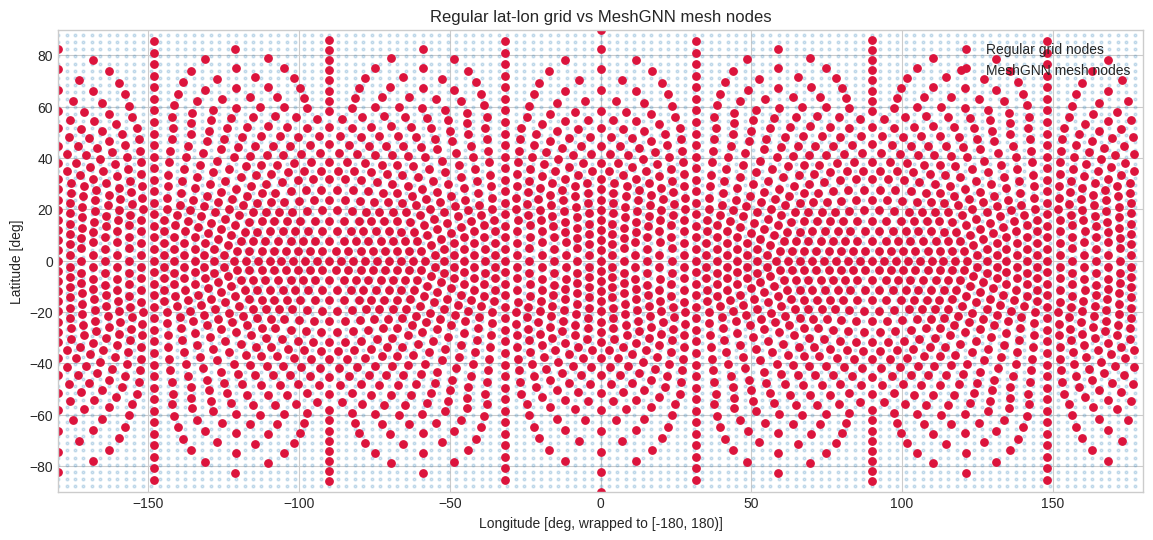

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(grid_lon_wrapped, grid_lat_deg, s=4, alpha=0.18, color='tab:blue', label='Regular grid nodes')
ax.scatter(mesh_lon_wrapped, mesh_lat_deg, s=28, color='crimson', label='MeshGNN mesh nodes')
ax.set_title('Regular lat-lon grid vs MeshGNN mesh nodes')
ax.set_xlabel('Longitude [deg, wrapped to [-180, 180)]')
ax.set_ylabel('Latitude [deg]')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.legend(loc='upper right')
plt.show()

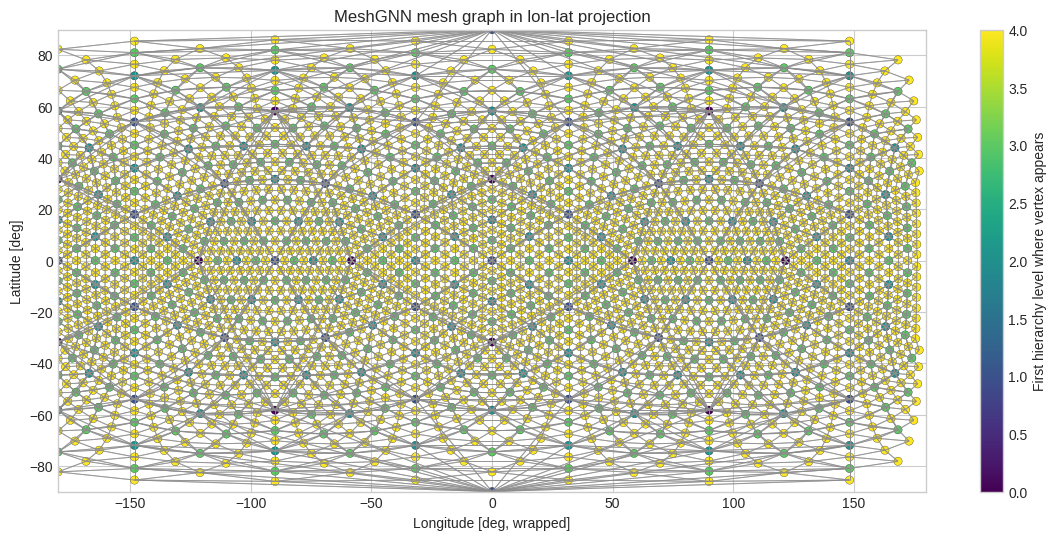

In [5]:
mesh_segments = build_segments(
    mesh_lon_wrapped,
    mesh_lat_deg,
    mesh_lon_wrapped,
    mesh_lat_deg,
    mesh_edge_index,
    sample_size=None,
)

fig, ax = plt.subplots(figsize=(14, 6))
mesh_lines = LineCollection(mesh_segments, colors='0.55', linewidths=0.7, alpha=0.7)
ax.add_collection(mesh_lines)
scatter = ax.scatter(
    mesh_lon_wrapped,
    mesh_lat_deg,
    c=as_numpy(static['mesh']['vertex_first_level']),
    cmap='viridis',
    s=36,
    edgecolors='black',
    linewidths=0.2,
)
ax.set_title('MeshGNN mesh graph in lon-lat projection')
ax.set_xlabel('Longitude [deg, wrapped]')
ax.set_ylabel('Latitude [deg]')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
plt.colorbar(scatter, ax=ax, label='First hierarchy level where vertex appears')
plt.show()

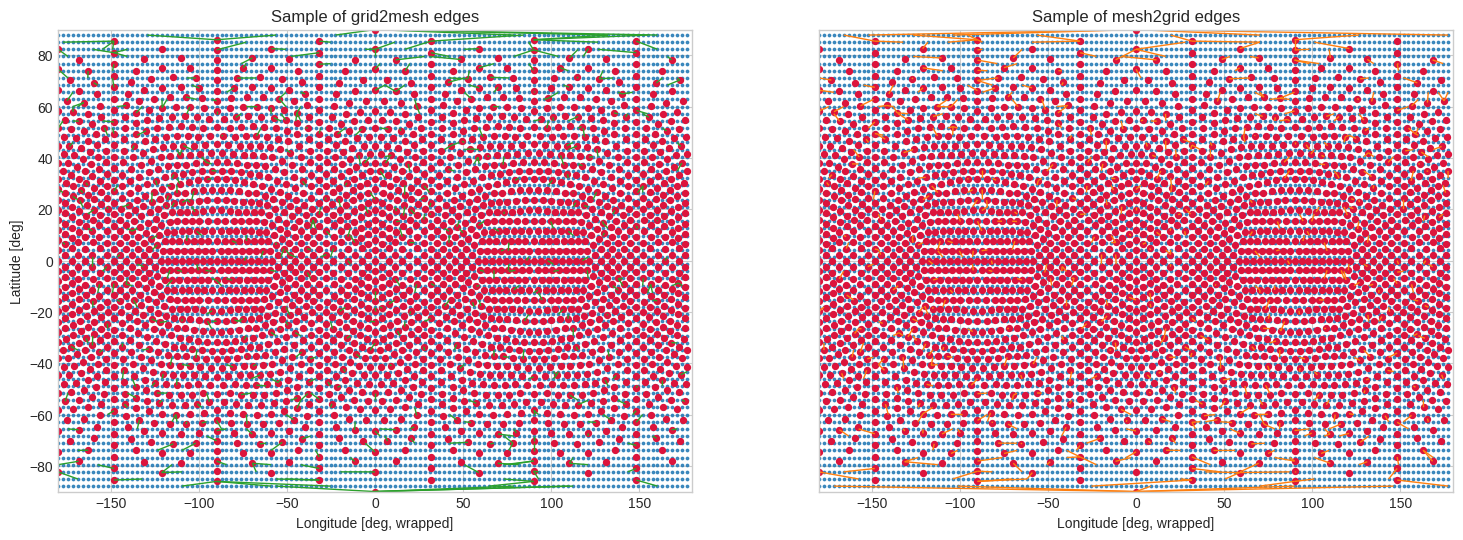

In [21]:
g2m_segments = build_segments(
    grid_lon_wrapped,
    grid_lat_deg,
    mesh_lon_wrapped,
    mesh_lat_deg,
    g2m_edge_index,
    sample_size=500,
    seed=7,
)

m2g_segments = build_segments(
    mesh_lon_wrapped,
    mesh_lat_deg,
    grid_lon_wrapped,
    grid_lat_deg,
    m2g_edge_index,
    sample_size=500,
    seed=11,
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)

axes[0].add_collection(LineCollection(g2m_segments, colors='tab:green', linewidths=1, alpha=1))
axes[0].scatter(grid_lon_wrapped, grid_lat_deg, s=3, alpha=0.8, color='tab:blue')
axes[0].scatter(mesh_lon_wrapped, mesh_lat_deg, s=18, color='crimson')
axes[0].set_title('Sample of grid2mesh edges')
axes[0].set_xlabel('Longitude [deg, wrapped]')
axes[0].set_ylabel('Latitude [deg]')

axes[1].add_collection(LineCollection(m2g_segments, colors='tab:orange', linewidths=1, alpha=1))
axes[1].scatter(grid_lon_wrapped, grid_lat_deg, s=3, alpha=0.8, color='tab:blue')
axes[1].scatter(mesh_lon_wrapped, mesh_lat_deg, s=18, color='crimson')
axes[1].set_title('Sample of mesh2grid edges')
axes[1].set_xlabel('Longitude [deg, wrapped]')

for ax in axes:
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

plt.show()

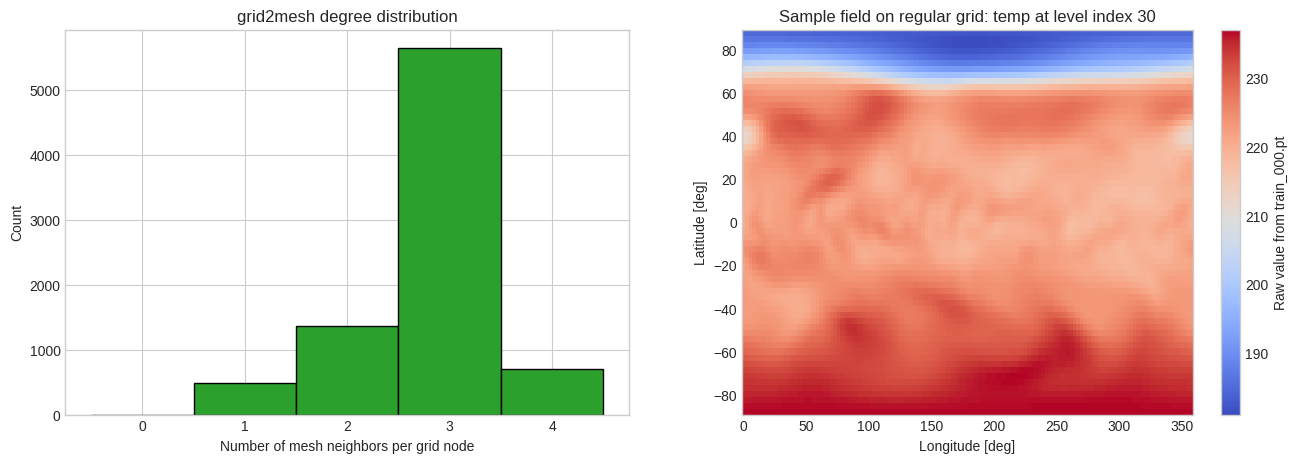

In [22]:
levels = manifest['grid']['level']
vars_ = manifest['dynamic_features']['vars']
n_levels = len(levels)
sample_time_idx = 0
sample_var = 'temp'
sample_level_idx = n_levels // 2
sample_feature_idx = vars_.index(sample_var) * n_levels + sample_level_idx
sample_field = as_numpy(train_shard['x_dyn'][sample_time_idx, :, sample_feature_idx]).reshape(grid_shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(g2m_grid_degree, bins=np.arange(g2m_grid_degree.max() + 2) - 0.5, color='tab:green', edgecolor='black')
axes[0].set_title('grid2mesh degree distribution')
axes[0].set_xlabel('Number of mesh neighbors per grid node')
axes[0].set_ylabel('Count')

mesh = axes[1].pcolormesh(
    as_numpy(static['grid']['lon_deg']),
    as_numpy(static['grid']['lat_deg']),
    sample_field,
    shading='auto',
    cmap='coolwarm',
)
axes[1].set_title(f"Sample field on regular grid: {sample_var} at level index {sample_level_idx}")
axes[1].set_xlabel('Longitude [deg]')
axes[1].set_ylabel('Latitude [deg]')
plt.colorbar(mesh, ax=axes[1], label='Raw value from train_000.pt')

plt.show()

In [23]:
import plotly.graph_objects as go


def plot_mesh_graph_3d_interactive(
    static,
    manifest,
    *,
    max_edges: int = 8000,
    seed: int = 0,
    show_nodes: bool = True,
    node_size: int = 3,
    edge_width: float = 1.0,
    edge_opacity: float = 0.20,
    background_for_poster: bool = False,
    renderer: str | None = None,
):
    """Interactive 3D visualization of the MeshGNN mesh graph on a sphere."""
    mesh_lat_rad = as_numpy(static["mesh"]["node_lat_rad"])
    mesh_lon_rad = as_numpy(static["mesh"]["node_lon_rad"])
    edge_index = as_numpy(static["mesh_graph"]["edge_index"])
    first_level = as_numpy(static["mesh"]["vertex_first_level"])

    x = np.cos(mesh_lat_rad) * np.cos(mesh_lon_rad)
    y = np.cos(mesh_lat_rad) * np.sin(mesh_lon_rad)
    z = np.sin(mesh_lat_rad)

    num_edges_total = edge_index.shape[1]
    n_edges = min(int(max_edges), int(num_edges_total))

    rng = np.random.default_rng(int(seed))
    if n_edges < num_edges_total:
        selected = rng.choice(num_edges_total, size=n_edges, replace=False)
    else:
        selected = np.arange(num_edges_total)

    src = edge_index[0, selected].astype(np.int64)
    dst = edge_index[1, selected].astype(np.int64)

    x_edges = np.empty(n_edges * 3, dtype=np.float64)
    y_edges = np.empty(n_edges * 3, dtype=np.float64)
    z_edges = np.empty(n_edges * 3, dtype=np.float64)

    x_edges[0::3] = x[src]
    x_edges[1::3] = x[dst]
    x_edges[2::3] = np.nan
    y_edges[0::3] = y[src]
    y_edges[1::3] = y[dst]
    y_edges[2::3] = np.nan
    z_edges[0::3] = z[src]
    z_edges[1::3] = z[dst]
    z_edges[2::3] = np.nan

    if background_for_poster:
        background_rgb = np.array([47, 62, 234], dtype=np.float64) / 255.0
        tint = 0.9
        boxcolor = (1.0 - tint) * background_rgb + tint * np.ones(3, dtype=np.float64)
        boxcolor_255 = np.clip(np.round(boxcolor * 255.0), 0, 255).astype(int)
        figure_bgcolor = f"rgb({boxcolor_255[0]}, {boxcolor_255[1]}, {boxcolor_255[2]})"
    else:
        figure_bgcolor = "white"

    fig = go.Figure()

    fig.add_trace(
        go.Scatter3d(
            x=x_edges,
            y=y_edges,
            z=z_edges,
            mode="lines",
            line=dict(color="rgba(40, 40, 40, 1.0)", width=edge_width),
            opacity=edge_opacity,
            name=f"Mesh edges ({n_edges}/{num_edges_total})",
            hoverinfo="skip",
        )
    )

    if show_nodes:
        fig.add_trace(
            go.Scatter3d(
                x=x,
                y=y,
                z=z,
                mode="markers",
                marker=dict(
                    size=node_size,
                    color=first_level,
                    colorscale="Viridis",
                    opacity=0.9,
                    colorbar=dict(title="vertex_first_level"),
                ),
                name=f"Mesh nodes ({x.shape[0]})",
                hovertemplate=(
                    "x=%{x:.3f}<br>y=%{y:.3f}<br>z=%{z:.3f}<br>"
                    "vertex_first_level=%{marker.color:.0f}<extra></extra>"
                ),
            )
        )

    fig.update_layout(
        title=(
            "MeshGNN Mesh Graph on Sphere "
            f"(dataset={manifest['dataset_name']})"
        ),
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            aspectmode="data",
            bgcolor=figure_bgcolor,
        ),
        paper_bgcolor=figure_bgcolor,
        width=900,
        height=900,
        margin=dict(l=0, r=0, t=60, b=0),
        legend=dict(yanchor="top", y=0.98, xanchor="left", x=0.02),
    )

    fig.show(renderer=renderer)
    return fig

In [24]:
_ = plot_mesh_graph_3d_interactive(
    static,
    manifest,
    max_edges=80000,
    seed=42,
    show_nodes=True,
    node_size=3,
    edge_width=1.0,
    edge_opacity=0.35,
    background_for_poster=True,
    renderer="browser",  # set to "notebook" if needed
)


## What To Notice

- The regular grid contains the atmospheric state values that came from the ISCA fields.
- The mesh is much smaller than the grid, which is the point of the MeshGNN latent graph.
- `grid2mesh` spreads each grid node to a handful of nearby mesh vertices.
- `mesh2grid` maps each grid node back from exactly three vertices in the containing finest-mesh triangle.
- The `train_000.pt` shard only stores dynamic grid-state tensors. The mesh itself lives in `mesh_gnn_static.pt`.